# Bayesian Hyperparameter Space Optimization and Automated Model Auditing Pipeline

In [1]:
%load_ext autoreload
%autoreload 2

import os
import mlflow
import optuna
from optuna.integration.mlflow import MLflowCallback
from optuna.pruners import MedianPruner
import numpy as np
import pandas as pd

from src import feature_engineering as fe
from src import optuna_optimization as utils
from src import mlflow_utils as mlf_utils

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Path Configuration & MLflow Backend Binding

In [2]:
RANDOM_STATE = 42
N_SPLITS = 5
EXPERIMENT_NAME = "customer-churn-optuna"

from pathlib import Path

def _find_project_root():
    """Find the project root by looking for pyproject.toml."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root (pyproject.toml)")

ROOT_DIR = str(_find_project_root())
DB_PATH = os.path.join(ROOT_DIR, "mlflow.db")
ARTIFACTS_DIR = os.path.join(ROOT_DIR, "mlartifacts")

# Set the tracking URI immediately to lock it to SQLite
mlflow.set_tracking_uri(f"sqlite:///{DB_PATH}")

# Explicitly create the experiment with your designated mlartifacts folder path
experiment_id = mlf_utils.init_mlflow_experiment(
    EXPERIMENT_NAME,
    DB_PATH,
    ARTIFACTS_DIR,
)

# Active the experiment scope
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='file:///Users/hector.vargas/repos/ml_hands_on_project/mlartifacts', creation_time=1781808230510, experiment_id='1', last_update_time=1781808230510, lifecycle_stage='active', name='customer-churn-optuna', tags={}, trace_location=None, workspace='default'>

## 2. Custom Source Code Ingestion

In [3]:
X_train = pd.read_csv("../data/processed/raw_features/X_train.csv")
X_test = pd.read_csv("../data/processed/raw_features/X_test.csv")
y_train = pd.read_csv("../data/processed/target/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/target/y_test.csv").squeeze()

## 2. Orchestrate and Initialize Search Parameter Studies

In [4]:
selected_features = [
    # Binary
    "is_silver",
    "is_germany",
    "is_spain",
    "Num_Of_Products_1",
    "Num_Of_Products_2",
    "Num_Of_Products_3",
    "Num_Of_Products_4",

    # Continuous
    "Age_x_IsActive",
    "Balance_per_Product",
    "CreditScore_per_Age",
    "Inactive_x_Balance",
    "CreditScore_x_Age",
    "Products_per_Tenure",
]
# Schema Baseline Columns Definitions
nomod_columns = []
dummyfy_columns = ['Gender']
norm_std_columns = ['Point Earned', 'Satisfaction Score', 'EstimatedSalary']

# Instantiate a blank engineer to discover internal method types
dummy_engineer = fe.DynamicFeatureEngineer()
class_binary_pool = dummy_engineer._get_all_binary_features()
class_continuous_pool = dummy_engineer._get_all_continuous_features()

# FIXED: Intersect your explicit selected_features list against class capacities
filtered_binary_features = [f for f in selected_features if f in class_binary_pool]
filtered_continuous_features = [f for f in selected_features if f in class_continuous_pool]

# Reconstruct current_layout using ONLY the isolated feature subsets
current_layout = {
    "passthrough": nomod_columns + filtered_binary_features,
    "standard_scale": norm_std_columns + filtered_continuous_features,
    "one_hot_encode": dummyfy_columns
}

EXPERIMENT_REGISTRY = {
    "experiment_1": current_layout
}

# Initialize Integrated MLflow Tracking Integration Callbacks
mlflow_callback = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="pr_auc",
    create_experiment=False,
    mlflow_kwargs={
        "nested": True,
        "experiment_id": experiment_id,
    },
)

study = optuna.create_study(
    study_name="customer-churn-rf-search-v1",
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)

# FIXED: Removed the invalid FULL_REGISTRY argument variable completely
# Instantiate the objective function with both training and testing datasets
objective_function = utils.ObjectiveCV(
    X=X_train,
    y=y_train,
    current_layout=current_layout,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
)

/var/folders/bv/50x24wc545x5mclk_t88ryrc0000gn/T/ipykernel_36129/1186269269.py:45: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflow_callback = MLflowCallback(
[I 2026-06-18 13:23:08,504] A new study created in memory with name: customer-churn-rf-search-v1


## 3. Run Optimization Search Workspace Execution Window

In [6]:
# Execute the parent run context block
with mlflow.start_run(
    run_name="optuna_search_parent",
    experiment_id=experiment_id,
):    
    study.optimize(
        objective_function,
        n_trials=500,
        callbacks=[mlflow_callback]
    )

    # Log global baseline metrics directly to the parent run metadata shell
    mlflow.log_metric("best_auc", study.best_value)
    mlflow.log_params(study.best_params)

    # Reconstruct the pipeline architecture using the best parameters found
    best_pipeline = utils.build_pipeline(
        trial=study.best_trial, 
        current_layout=current_layout,
        random_state=RANDOM_STATE
    )

    # Fit the components using your training slice to initialize column shapes
    best_pipeline.named_steps["feature_engineering"].fit(X_train)
    X_engineered = best_pipeline.named_steps["feature_engineering"].transform(X_train)

    # Fit the preprocessing steps on the engineered matrix
    best_pipeline.named_steps["preprocessing"].fit(X_engineered)
    final_feature_names = best_pipeline.named_steps["preprocessing"].get_feature_names_out().tolist()

    print(f" Total features entering the model: {len(final_feature_names)}")
    print("\n--- Definitive Feature Inventory Passing to Classifier ---")
    for idx, feature in enumerate(sorted(final_feature_names), 1):
        print(f" {idx:02d}. {feature}")


    # Run full evaluations and save serialization schema artifacts to the parent run
    utils.evaluate_and_log_best_model(
        best_pipeline=best_pipeline,
        X_train=X_train, 
        y_train=y_train,
        X_test=X_test, 
        y_test=y_test,
        current_layout=current_layout,
    )

[I 2026-06-18 13:24:03,015] Trial 2 finished with value: 0.6830187400624312 and parameters: {'scaler': 'robust', 'encoder': 'no_drop', 'model': 'rf', 'rf_n_estimators': 295, 'rf_max_depth': 13, 'rf_min_samples_split': 26, 'rf_min_samples_leaf': 1}. Best is trial 0 with value: 0.683240846340144.
[I 2026-06-18 13:24:03,243] Trial 3 finished with value: 0.6948109142821064 and parameters: {'scaler': 'minmax', 'encoder': 'no_drop', 'model': 'xgb', 'xgb_n_estimators': 1107, 'xgb_learning_rate': 0.03155479226944651, 'xgb_subsample': 0.9555855538044705, 'xgb_colsample_bytree': 0.5280102031766716, 'xgb_gamma': 3.318684111737312, 'xgb_reg_alpha': 3.5856126103453994e-09, 'xgb_reg_lambda': 7.045683638454505e-05, 'xgb_scale_pos_weight': 1.5650796940166687}. Best is trial 3 with value: 0.6948109142821064.
[I 2026-06-18 13:24:05,053] Trial 4 finished with value: 0.6809499987370577 and parameters: {'scaler': 'std', 'encoder': 'drop_first', 'model': 'rf', 'rf_n_estimators': 285, 'rf_max_depth': 10, 'rf

 Total features entering the model: 18

--- Definitive Feature Inventory Passing to Classifier ---
 01. cat__Gender_Female
 02. cat__Gender_Male
 03. num__Age_x_IsActive
 04. num__Balance_per_Product
 05. num__CreditScore_per_Age
 06. num__CreditScore_x_Age
 07. num__EstimatedSalary
 08. num__Inactive_x_Balance
 09. num__Point Earned
 10. num__Products_per_Tenure
 11. num__Satisfaction Score
 12. pass__Num_Of_Products_1
 13. pass__Num_Of_Products_2
 14. pass__Num_Of_Products_3
 15. pass__Num_Of_Products_4
 16. pass__is_germany
 17. pass__is_silver
 18. pass__is_spain


2026/06/18 13:26:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/18 13:26:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## 4. Display Session Optimization Diagnostics Results

In [7]:
print(f"\nTop Optimization Average Precision Score Target: {study.best_value:.4f}")
print("\nOptimal Parameter Combinations Selected:")
for parameter_key, parameter_value in study.best_params.items():
    print(f" * {parameter_key}: {parameter_value}")


Top Optimization Average Precision Score Target: 0.6977

Optimal Parameter Combinations Selected:
 * scaler: robust
 * encoder: no_drop
 * model: xgb
 * xgb_n_estimators: 1403
 * xgb_learning_rate: 0.028208365131823353
 * xgb_subsample: 0.9741488207907273
 * xgb_colsample_bytree: 0.5163311685111722
 * xgb_gamma: 3.2099584250585966
 * xgb_reg_alpha: 2.7442001852027416e-07
 * xgb_reg_lambda: 3.527615965634737e-07
 * xgb_scale_pos_weight: 1.189474235403715


In [8]:
suggestions = utils.suggest_numeric_ranges(study)
display(suggestions)

,parameter,current_min,current_max,best_median,action,suggested_min,suggested_max
0,xgb_reg_lambda,1.102323e-09,9.854203e-05,3.836878e-05,keep,1.102323e-09,9.854203e-05
1,xgb_scale_pos_weight,1.100395e+00,1.565080e+00,1.155016e+00,move_left,8.680525e-01,1.565080e+00
2,xgb_colsample_bytree,4.637524e-01,5.905221e-01,5.191739e-01,narrow,5.135998e-01,5.288977e-01
3,xgb_gamma,3.102651e+00,3.465806e+00,3.230303e+00,narrow,3.200648e+00,3.265578e+00
4,xgb_learning_rate,1.808920e-02,3.732513e-02,2.830736e-02,narrow,2.790013e-02,2.910770e-02
5,xgb_n_estimators,9.020000e+02,1.692000e+03,1.497500e+03,narrow,1.361300e+03,1.621000e+03
6,xgb_reg_alpha,1.000248e-09,9.956056e-07,2.380118e-07,narrow,1.501798e-07,3.510699e-07
7,xgb_subsample,9.402761e-01,9.898735e-01,9.742365e-01,narrow,9.723397e-01,9.750881e-01


In [9]:
runs_df = mlflow.search_runs()
# Select rows where 'tags.mlflow.parentRunId' is missing (meaning it IS a parent/master run)
parent_summary_df = runs_df[runs_df["tags.mlflow.parentRunId"].isna() & (runs_df["status"] == "FINISHED")]

# Isolate evaluation metrics
metric_cols = [c for c in parent_summary_df.columns if c.startswith("metrics.")]
display(parent_summary_df[["start_time"] + metric_cols])

,start_time,metrics.pr_auc,metrics.test_accuracy,metrics.train_f1,metrics.best_auc,metrics.train_precision,metrics.test_roc_auc,metrics.test_pr_auc,metrics.train_roc_auc,metrics.train_pr_auc,metrics.test_f1,metrics.train_recall,metrics.test_precision,metrics.test_recall,metrics.train_accuracy
500,2026-06-18 19:24:01.029000+00:00,NaN,0.8725,0.673933,0.697662,0.826281,0.874181,0.734104,0.915593,0.796508,0.643357,0.569018,0.749186,0.563725,0.887813
1005,2026-06-18 19:13:48.547000+00:00,NaN,0.8725,0.681540,0.697123,0.793279,0.875437,0.734021,0.918387,0.799607,0.650206,0.597393,0.738318,0.580882,0.886250
6006,2026-06-18 18:44:13.563000+00:00,NaN,0.8725,0.681540,0.697123,0.793279,0.875437,0.734021,0.918387,0.799607,0.650206,0.597393,0.738318,0.580882,0.886250
6012,2026-06-18 18:43:50.751000+00:00,NaN,0.8675,0.725627,0.692373,0.782609,0.872410,0.731174,0.936620,0.831847,0.654498,0.676380,0.699164,0.615196,0.895781


In [10]:
run_id = parent_summary_df.iloc[0]["run_id"]

run = mlflow.get_run(run_id)

print(run.data.metrics)

{'best_auc': 0.6976624242884706, 'train_accuracy': 0.8878125, 'train_precision': 0.8262806236080178, 'train_recall': 0.5690184049079755, 'train_f1': 0.6739327883742052, 'train_roc_auc': 0.9155927059356068, 'train_pr_auc': 0.7965081638080406, 'test_accuracy': 0.8725, 'test_precision': 0.749185667752443, 'test_recall': 0.5637254901960784, 'test_f1': 0.6433566433566433, 'test_roc_auc': 0.8741809537885505, 'test_pr_auc': 0.734104011339465}


In [11]:
parent_summary_df

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.pr_auc,metrics.test_accuracy,metrics.train_f1,metrics.best_auc,...,tags.model_distribution,tags.xgb_gamma_distribution,tags.xgb_reg_lambda_distribution,tags.xgb_colsample_bytree_distribution,tags.mlflow.user,tags.xgb_reg_alpha_distribution,tags.rf_min_samples_split_distribution,tags.rf_min_samples_leaf_distribution,tags.rf_n_estimators_distribution,tags.rf_max_depth_distribution
500,3baa83fba10949f99b4d570322b85014,1,FINISHED,file:///Users/hector.vargas/repos/ml_hands_on_...,2026-06-18 19:24:01.029000+00:00,2026-06-18 19:26:22.876000+00:00,NaN,0.8725,0.673933,0.697662,...,None,None,None,None,hector.vargas,None,None,None,None,None
1005,3e9f1ecb05c1451e82b69756551d7bf4,1,FINISHED,file:///Users/hector.vargas/repos/ml_hands_on_...,2026-06-18 19:13:48.547000+00:00,2026-06-18 19:17:09.850000+00:00,NaN,0.8725,0.681540,0.697123,...,None,None,None,None,hector.vargas,None,None,None,None,None
6006,6df14e85472948e7bdfaa8ce1646f64e,1,FINISHED,file:///Users/hector.vargas/repos/ml_hands_on_...,2026-06-18 18:44:13.563000+00:00,2026-06-18 19:07:50.515000+00:00,NaN,0.8725,0.681540,0.697123,...,None,None,None,None,hector.vargas,None,None,None,None,None
6012,2fec598b531445bfab986c3513d398fd,1,FINISHED,file:///Users/hector.vargas/repos/ml_hands_on_...,2026-06-18 18:43:50.751000+00:00,2026-06-18 18:44:00.873000+00:00,NaN,0.8675,0.725627,0.692373,...,None,None,None,None,hector.vargas,None,None,None,None,None


In [ ]:
# from src import feature_engineering as fe
# fe.remove_recent_runs(EXPERIMENT_NAME, 100000)

In [12]:
rf_runs = (
    parent_summary_df[parent_summary_df["params.model"] == "rf"]
    .sort_values(
        "metrics.train_pr_auc",
        ascending=False
    )
)

rf_runs[
    [
        "run_id",
        'metrics.train_pr_auc',
        "metrics.pr_auc",
        "params.rf_max_depth",
        "params.rf_n_estimators",
        "params.rf_min_samples_split",
        "params.rf_min_samples_leaf",
    ]
]

,run_id,metrics.train_pr_auc,metrics.pr_auc,params.rf_max_depth,params.rf_n_estimators,params.rf_min_samples_split,params.rf_min_samples_leaf


In [13]:
xgb_runs = (
    parent_summary_df[parent_summary_df["params.model"] == "xgb"]
    .sort_values(
        "metrics.train_pr_auc",
        ascending=False
    )
)

xgb_runs[
    [
        "run_id",
        "metrics.train_pr_auc",
        "metrics.test_pr_auc",
        "metrics.pr_auc",
        "params.xgb_n_estimators",
        "params.xgb_learning_rate",
        "params.xgb_gamma",
        "params.xgb_scale_pos_weight",
    ]
].head(20)

,run_id,metrics.train_pr_auc,metrics.test_pr_auc,metrics.pr_auc,params.xgb_n_estimators,params.xgb_learning_rate,params.xgb_gamma,params.xgb_scale_pos_weight
6012,2fec598b531445bfab986c3513d398fd,0.831847,0.731174,NaN,1059,0.023037644267552806,2.5427182267774797,1.6925879806965067
1005,3e9f1ecb05c1451e82b69756551d7bf4,0.799607,0.734021,NaN,1344,0.029996787981120963,3.3526627546816017,1.3332972021886085
6006,6df14e85472948e7bdfaa8ce1646f64e,0.799607,0.734021,NaN,1344,0.029996787981120963,3.3526627546816017,1.3332972021886085
500,3baa83fba10949f99b4d570322b85014,0.796508,0.734104,NaN,1403,0.028208365131823353,3.2099584250585966,1.189474235403715


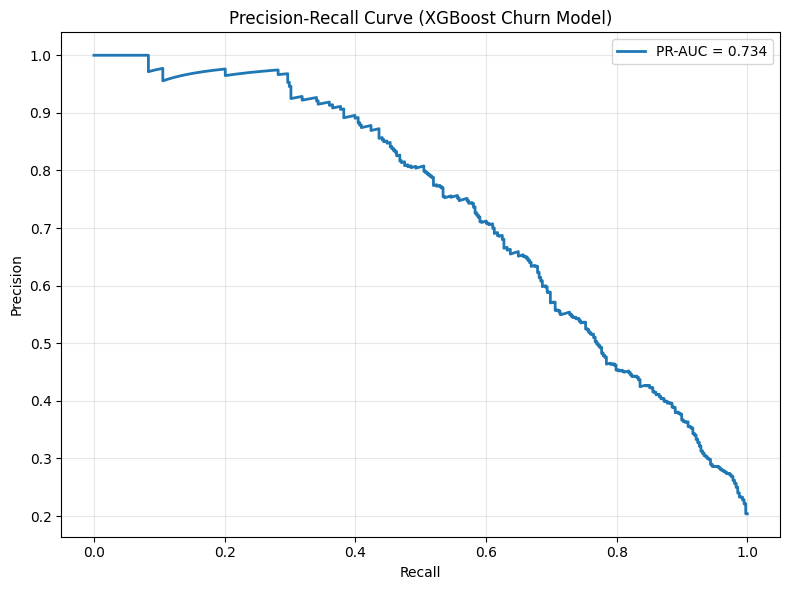

In [14]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Probabilities for the positive (churn) class
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

# Compute AP (same metric optimized in Optuna)
pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

# Plot
plt.figure(figsize=(8,6))
plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost Churn Model)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

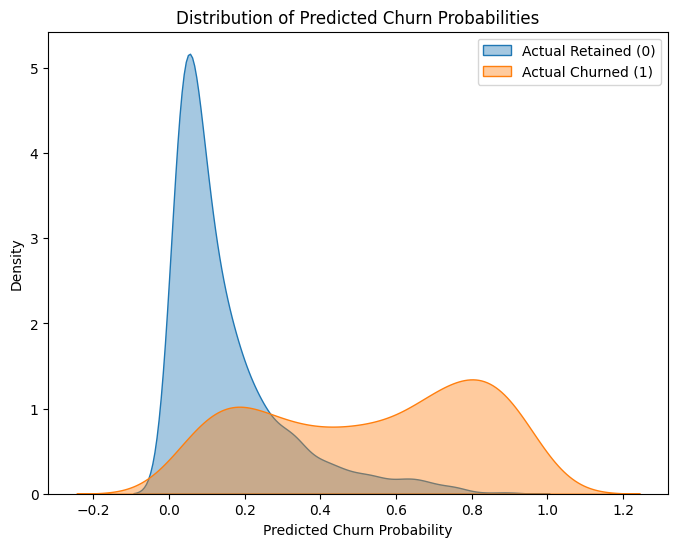

In [15]:
import seaborn as sns

plot_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted Probability": y_test_proba
})

plt.figure(figsize=(8,6))

sns.kdeplot(
    data=plot_df[plot_df["Actual"] == 0],
    x="Predicted Probability",
    fill=True,
    alpha=0.4,
    label="Actual Retained (0)"
)

sns.kdeplot(
    data=plot_df[plot_df["Actual"] == 1],
    x="Predicted Probability",
    fill=True,
    alpha=0.4,
    label="Actual Churned (1)"
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Density")
plt.title("Distribution of Predicted Churn Probabilities")
plt.legend()
plt.show()

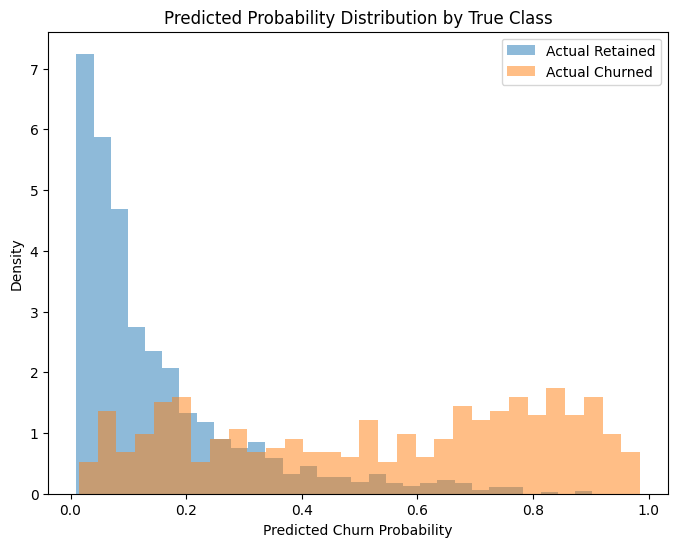

In [16]:
plt.figure(figsize=(8,6))

plt.hist(
    y_test_proba[y_test == 0],
    bins=30,
    alpha=0.5,
    density=True,
    label="Actual Retained"
)

plt.hist(
    y_test_proba[y_test == 1],
    bins=30,
    alpha=0.5,
    density=True,
    label="Actual Churned"
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution by True Class")
plt.legend()
plt.show()

In [ ]:
y_train_proba = best_pipeline.predict_proba(X_train)[:, 1]
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

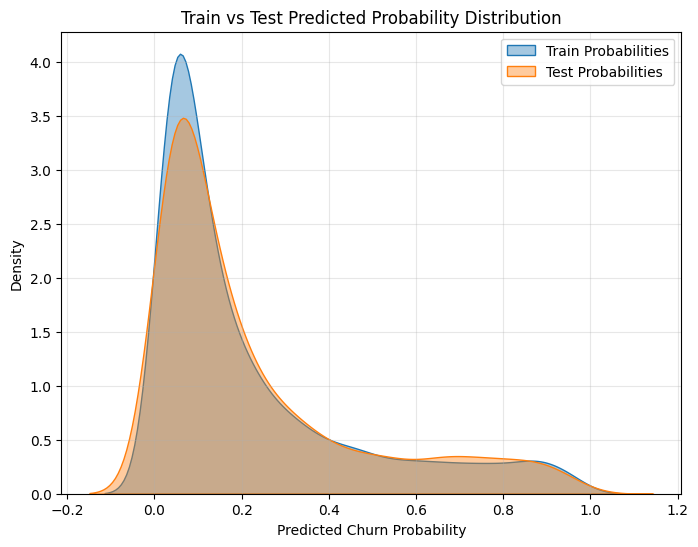

In [18]:
plt.figure(figsize=(8, 6))

sns.kdeplot(
    y_train_proba,
    fill=True,
    alpha=0.4,
    label="Train Probabilities"
)

sns.kdeplot(
    y_test_proba,
    fill=True,
    alpha=0.4,
    label="Test Probabilities"
)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Density")
plt.title("Train vs Test Predicted Probability Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.show()